In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# تحميل الـ iris dataset
iris = load_iris()
X = iris.data                         # الـ features (150 صف × 4 columns)
y = iris.target     # الـ labels الحقيقية (مش هنستخدمها في الـ clustering)
feature_names = iris.feature_names

# نحول لـ DataFrame عشان نشوف الداتا
df = pd.DataFrame(X, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
# الـ K-Means حساس جداً للـ scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
# K=3 لأن الـ iris عندها 3 أنواع فعلاً
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',     # أحسن من random
    max_iter=300,        # أقصى عدد iterations
    n_init=10,           # بيجرب 10 مرات ويأخد الأحسن
    random_state=42
)

kmeans.fit(X_scaled)
labels = kmeans.labels_            # الـ cluster لكل نقطة
centroids = kmeans.cluster_centers_ # مراكز الـ clusters

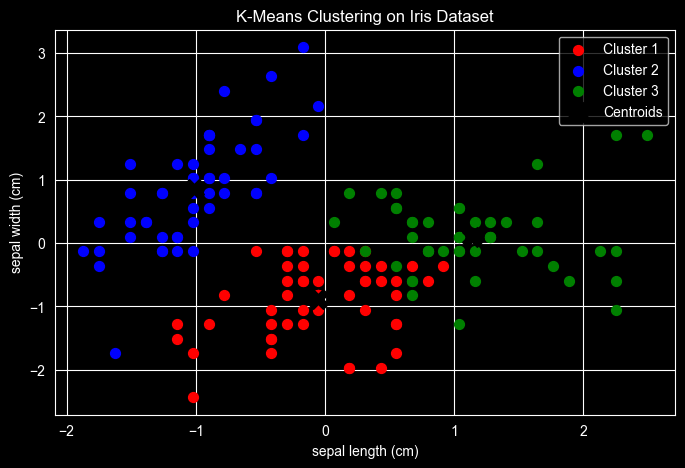

In [5]:
# بنرسم أول feature مع تاني feature
plt.figure(figsize=(8, 5))

colors = ['red', 'blue', 'green']
for i in range(3):
    plt.scatter(
        X_scaled[labels == i, 0],
        X_scaled[labels == i, 1],
        c=colors[i], label=f'Cluster {i+1}', s=50
    )

# رسم الـ Centroids
plt.scatter(
    centroids[:, 0], centroids[:, 1],
    c='black', marker='X', s=200, label='Centroids'
)

plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.legend()
plt.title('K-Means Clustering on Iris Dataset')
plt.show()

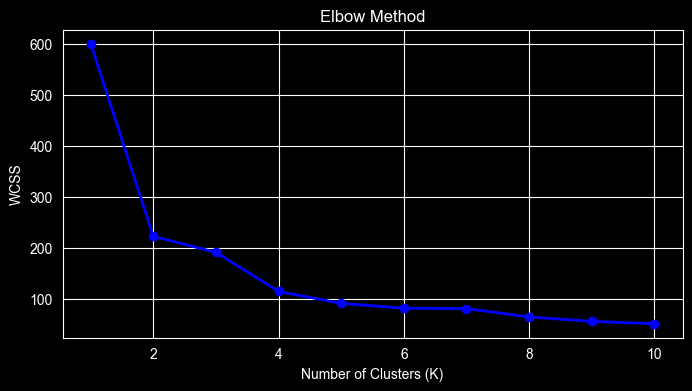

In [6]:
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# رسم الـ Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, 'bo-', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [8]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, labels)
print(f"Silhouette Score: {score:.3f}")
# القيمة بين -1 و 1 — كلما اقتربت من 1 كلما كان الـ clustering أحسن

print(f"WCSS (Inertia): {kmeans.inertia_:.2f}")

Silhouette Score: 0.460
WCSS (Inertia): 51.12
